In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/salaries_by_college_major.csv")

In [12]:
df.head(2)

,Undergraduate Major,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 90th Percentile Salary,Group
0,Accounting,46000.0,77100.0,42200.0,152000.0,Business
1,Aerospace Engineering,57700.0,101000.0,64300.0,161000.0,STEM


In [13]:
df.shape

(51, 6)

**Not a Number Values**

In [3]:
df.isna().sum()

Undergraduate Major                  0
Starting Median Salary               1
Mid-Career Median Salary             1
Mid-Career 10th Percentile Salary    1
Mid-Career 90th Percentile Salary    1
Group                                1
dtype: int64

In [4]:
df[df.Group.isna()]

,Undergraduate Major,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 90th Percentile Salary,Group
50,Source: PayScale Inc.,NaN,NaN,NaN,NaN,NaN


In [5]:
clean_df = df.dropna()

In [6]:
clean_df.isna().sum()

Undergraduate Major                  0
Starting Median Salary               0
Mid-Career Median Salary             0
Mid-Career 10th Percentile Salary    0
Mid-Career 90th Percentile Salary    0
Group                                0
dtype: int64

**Highest Mid-Career Salary**

In [7]:
row_index = clean_df['Mid-Career Median Salary'].idxmax()
print(f"""
{df['Undergraduate Major'].loc[row_index]} has the highest mid-career salary by
${df['Mid-Career Median Salary'].loc[row_index]}
""")


Chemical Engineering has the highest mid-career salary by
$107000.0



**Insert Column**

Spread of Earnings

In [8]:
spread_col = clean_df['Mid-Career 90th Percentile Salary'] - clean_df['Mid-Career 10th Percentile Salary']
clean_df.insert(1, 'Spread', spread_col)

**Sort Values**

In [9]:
low_risk = clean_df.sort_values('Spread')
high_risk = clean_df.sort_values('Spread', ascending=False)
top_earnings_potential = clean_df.sort_values('Mid-Career 90th Percentile Salary', ascending=False)

**Group**

In [66]:
clean_df.groupby('Group').count()
group_df = clean_df.groupby('Group').mean(numeric_only =True)
group_df.head()

,Spread,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 90th Percentile Salary
Group,,,,,
Business,103958.333333,44633.333333,75083.333333,43566.666667,147525.000000
HASS,95218.181818,37186.363636,62968.181818,34145.454545,129363.636364
STEM,101600.000000,53862.500000,90812.500000,56025.000000,157625.000000


**Pivot**

In [11]:
pivot_df = clean_df.pivot(index='Undergraduate Major', columns='Group', values='Spread')
pivot_df.fillna(0, inplace=True)
pivot_df.head(2)

Group,Business,HASS,STEM
Undergraduate Major,,,
Accounting,109800.0,0.0,0.0
Aerospace Engineering,0.0,0.0,96700.0


**Plot**

In [17]:
import matplotlib.pyplot as plt

<Axes: xlabel='Group'>

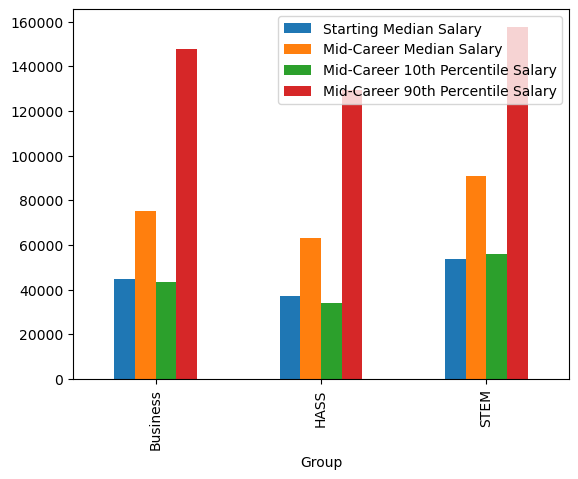

In [70]:
group_df.iloc[:, 1:].plot.bar()

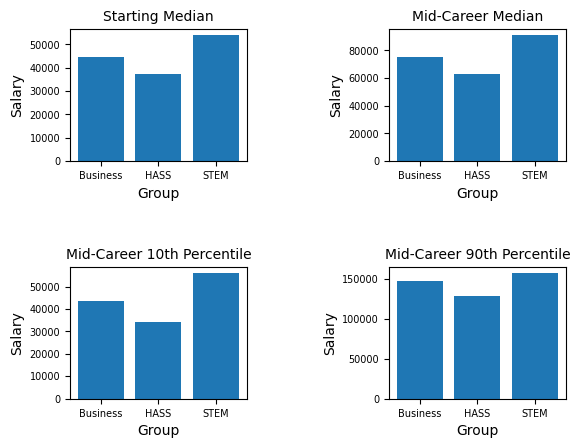

In [107]:
fig, axes = plt.subplots(2,2)

for i in range(len(axes)):
    if i == 0:
        num = 0
    for j in range(len(axes[i])):
        col = group_df.iloc[:, 1:].columns[num]
        axes[i,j].bar(group_df.iloc[:, 1:].index, group_df.iloc[:, 1:][col])
        axes[i,j].set_title(col[:-7], fontsize=10)
        axes[i,j].set_xlabel('Group')
        axes[i,j].set_ylabel('Salary')
        axes[i,j].tick_params(axis='both', labelsize=7)
        num += 1

# fig.subtitle('SubTitle')
plt.subplots_adjust(wspace=0.8, hspace=0.8)